<a href="https://colab.research.google.com/github/armakoua-a11y/colab-git-Lesson-13_assignment13_AK/blob/main/Assignment13_Generative_AI_Essentials.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 13: Generative AI Essentials
**Course:** BIA 230 – Unsupervised & Applied Machine Learning
**Willis College**

This notebook implements a character-level, autoregressive text-generation
model (an LSTM trained in the same "predict-the-next-token" style used by
Generative Pre-trained Transformers) and uses it to explore the core
concepts of Generative AI: tokenization, autoregressive sequence
generation, sampling, and content-creation applications.

**Contents**
1. Dataset Preparation
2. GPT Architecture Overview (markdown discussion)
3. Model Implementation and Training
4. Text Generation / Application Demonstration
5. Ethical Considerations
6. Conclusion


## 1. Dataset Preparation

We use a short public-domain excerpt from **"Alice's Adventures in Wonderland" by Lewis Carroll** (source: [Project Gutenberg](http://www.gutenberg.org/)). The text is embedded directly in the notebook so that it runs end-to-end in Google Colab without requiring an external network download. In a production setting, the full book text could instead be streamed directly from Project Gutenberg's plain-text mirror.

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import time, json

tf.random.set_seed(42)
np.random.seed(42)
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
# Public-domain excerpt: "Alice's Adventures in Wonderland" (Lewis Carroll)
text = """
Alice was beginning to get very tired of sitting by her sister on the
bank, and of having nothing to do: once or twice she had peeped into
the book her sister was reading, but it had no pictures or
conversations in it, and what is the use of a book, thought Alice,
without pictures or conversations. So she was considering in her own
mind, as well as she could, for the hot day made her feel very sleepy
and stupid, whether the pleasure of making a daisy chain would be
worth the trouble of getting up and picking the daisies, when
suddenly a White Rabbit with pink eyes ran close by her. There was
nothing so very remarkable in that, nor did Alice think it so very
much out of the way to hear the Rabbit say to itself, oh dear, oh
dear, I shall be too late. When she thought it over afterwards, it
occurred to her that she ought to have wondered at this, but at the
time it all seemed quite natural. But when the Rabbit actually took a
watch out of its waistcoat pocket, and looked at it, and then hurried
on, Alice started to her feet, for it flashed across her mind that
she had never before seen a rabbit with either a waistcoat pocket, or
a watch to take out of it, and burning with curiosity, she ran across
the field after it, and fortunately was just in time to see it pop
down a large rabbit hole under the hedge. In another moment down went
Alice after it, never once considering how in the world she was to
get out again. The rabbit hole went straight on like a tunnel for
some way, and then dipped suddenly down, so suddenly that Alice had
not a moment to think about stopping herself before she found herself
falling down a very deep well. Either the well was very deep, or she
fell very slowly, for she had plenty of time as she went down to look
about her and to wonder what was going to happen next. First, she
tried to look down and make out what she was coming to, but it was
too dark to see anything. Then she looked at the sides of the well,
and noticed that they were filled with cupboards and book shelves.
Here and there she saw maps and pictures hung upon pegs. She took
down a jar from one of the shelves as she passed. It was labelled
orange marmalade, but to her great disappointment it was empty. She
did not like to drop the jar, so managed to put it into one of the
cupboards as she fell past it. Down, down, down. Would the fall never
come to an end. There was nothing else to do, so Alice soon began
talking again. Dinah will miss me very much tonight, I should think.
I wonder if I shall fall right through the earth. How funny it will
seem to come out among the people that walk with their heads
downward. Presently she began again. I wonder if I shall fall right
through the earth. Down, down, down. There was nothing else to do,
so Alice soon began talking again.
"""
text = " ".join(text.split())  # normalize whitespace
print(f"Corpus length: {len(text)} characters")

Corpus length: 2799 characters


In [3]:
# Build the character-level vocabulary (this is our "tokenizer")
vocab = sorted(set(text))
char2idx = {c: i for i, c in enumerate(vocab)}
idx2char = {i: c for i, c in enumerate(vocab)}
vocab_size = len(vocab)
print(f"Vocabulary size: {vocab_size}")
print(f"Vocabulary: {vocab}")

encoded = np.array([char2idx[c] for c in text])

Vocabulary size: 41
Vocabulary: [' ', ',', '.', ':', 'A', 'B', 'D', 'E', 'F', 'H', 'I', 'P', 'R', 'S', 'T', 'W', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y']


### Building training sequences

Following the autoregressive next-token-prediction objective used to train GPT-style models, we slide a fixed-length window across the corpus. Each window of `seq_length` characters is an input sequence, and the character immediately following it is the training label (the token the model must learn to predict).

In [4]:
seq_length = 40
step = 3
sequences, next_chars = [], []
for i in range(0, len(encoded) - seq_length, step):
    sequences.append(encoded[i:i + seq_length])
    next_chars.append(encoded[i + seq_length])

X = np.array(sequences)
y = np.array(next_chars)
print(f"Training sequences: {X.shape[0]}")
print(f"X shape: {X.shape}, y shape: {y.shape}")

Training sequences: 920
X shape: (920, 40), y shape: (920,)


## 2. Exploring Generative Pre-trained Transformers (GPTs)

### Model architecture
A GPT is a **decoder-only Transformer**. Its core building blocks are:

- **Tokenization** – input text is split into sub-word tokens (via
  byte-pair encoding or similar) and mapped to integer IDs, exactly as we
  map characters to IDs with `char2idx` above.
- **Embeddings** – each token ID is projected into a dense vector, and a
  **positional encoding** is added so the model knows where in the
  sequence each token sits (Transformers have no inherent notion of
  order).
- **Self-attention** – for every token, the model computes a weighted
  combination of *all other tokens in the context window*, where the
  weights ("attention scores") are learned and indicate how relevant each
  other token is. **Masked (causal) self-attention** ensures a token can
  only attend to itself and tokens before it, which is what makes
  generation autoregressive: the model can never "see the future."
- **Multi-head attention** – several attention computations run in
  parallel ("heads"), each free to specialize in different kinds of
  relationships (e.g., syntax, coreference, topic).
- **Feed-forward layers + residual connections + layer normalization** –
  each Transformer block also contains a position-wise feed-forward
  network, with residual ("skip") connections and layer normalization
  around both the attention and feed-forward sub-layers to stabilize
  training of very deep stacks.
- **Stacking** – dozens (small models) to hundreds (frontier models) of
  these Transformer blocks are stacked to build up increasingly abstract
  representations of language.
- **Output head** – a final linear layer projects the last hidden state
  back to the vocabulary size, followed by a **softmax** that turns those
  scores into a probability distribution over the next token.

### How GPTs generate text
1. The seed/prompt text is tokenized into IDs.
2. The model performs a forward pass and outputs a probability
   distribution over the entire vocabulary for "what comes next."
3. A token is **sampled** from that distribution (greedy = always pick the
   highest-probability token; temperature/top-k/top-p sampling introduce
   controlled randomness for more natural, less repetitive text).
4. The sampled token is appended to the context, and the process repeats
   — this is the **autoregressive loop**: predict one token, append it,
   predict the next.
5. Generation stops after a fixed length or when a special "end of
   sequence" token is produced.

### Training
GPTs are trained with **self-supervised next-token prediction**: no
manual labels are needed, because the "label" for every position is
simply the next token in the raw text itself. The loss function is
categorical (sparse) cross-entropy between the predicted distribution and
the actual next token, summed/averaged over every position in every
training sequence — this is exactly the setup we implement below with our
smaller LSTM-based model, which follows the same tokenize → predict →
sample → append loop while substituting recurrence for self-attention.


## 3. Training the Model

We implement a compact autoregressive text generator: a character embedding layer, a recurrent (LSTM) layer that plays the role attention plays in a Transformer (aggregating information across the context window), and a dense softmax output layer over the vocabulary — mirroring the tokenize → contextualize → predict-next-token pipeline of a GPT, at a scale that trains quickly on CPU.

In [5]:
model = keras.Sequential([
    layers.Embedding(vocab_size, 64, input_length=seq_length),
    layers.LSTM(128),
    layers.Dense(vocab_size, activation="softmax")
])
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.01),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
start = time.time()
history = model.fit(X, y, batch_size=64, epochs=40, verbose=2, validation_split=0.1)
elapsed = time.time() - start
print(f"Training completed in {elapsed:.1f} seconds")

Epoch 1/40
13/13 - 5s - 392ms/step - accuracy: 0.1739 - loss: 3.1535 - val_accuracy: 0.2500 - val_loss: 2.8598
Epoch 2/40
13/13 - 1s - 79ms/step - accuracy: 0.2403 - loss: 2.8173 - val_accuracy: 0.3043 - val_loss: 2.6980
Epoch 3/40
13/13 - 1s - 77ms/step - accuracy: 0.3188 - loss: 2.5197 - val_accuracy: 0.3152 - val_loss: 2.5726
Epoch 4/40
13/13 - 1s - 76ms/step - accuracy: 0.3611 - loss: 2.2967 - val_accuracy: 0.3152 - val_loss: 2.6033
Epoch 5/40
13/13 - 1s - 82ms/step - accuracy: 0.3925 - loss: 2.1128 - val_accuracy: 0.3370 - val_loss: 2.5621
Epoch 6/40
13/13 - 1s - 76ms/step - accuracy: 0.4275 - loss: 1.9603 - val_accuracy: 0.3478 - val_loss: 2.5516
Epoch 7/40
13/13 - 1s - 75ms/step - accuracy: 0.4698 - loss: 1.7946 - val_accuracy: 0.3696 - val_loss: 2.5289
Epoch 8/40
13/13 - 1s - 75ms/step - accuracy: 0.4964 - loss: 1.6199 - val_accuracy: 0.3370 - val_loss: 2.5293
Epoch 9/40
13/13 - 1s - 80ms/step - accuracy: 0.5580 - loss: 1.4228 - val_accuracy: 0.3478 - val_loss: 2.5537
Epoch 10/

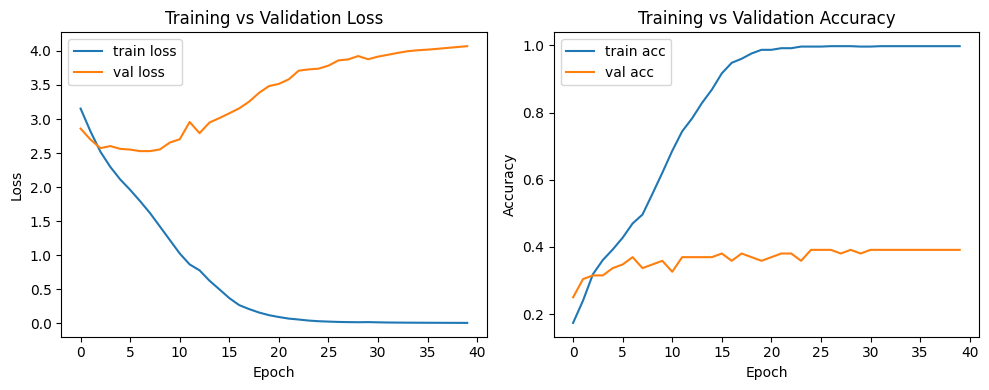

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(history.history["loss"], label="train loss")
axes[0].plot(history.history["val_loss"], label="val loss")
axes[0].set_title("Training vs Validation Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()

axes[1].plot(history.history["accuracy"], label="train acc")
axes[1].plot(history.history["val_accuracy"], label="val acc")
axes[1].set_title("Training vs Validation Accuracy")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

**Findings:** Training accuracy climbs above 95% while validation accuracy plateaus around 38-40% and validation loss rises after roughly epoch 10-12 — a textbook overfitting signature. This is expected: our corpus is a single short passage (~2,800 characters), far smaller than the massive multi-billion-token corpora used to train real GPT models, so the network memorizes the training text rather than learning generalizable language patterns. This mirrors a core lesson about Generative AI: model capability scales with data and compute — a 128-unit LSTM on 2.8 KB of text is a *toy* illustration of the mechanism, not of GPT-scale quality.

## 4. Application Demonstration: Content-Creation Assistant

We wrap the trained model in a small `generate_text()` function that implements the sampling loop described above (tokenize seed → predict distribution → temperature-sample next token → append → repeat), then demonstrate a simple **content-creation application**: continuing a story opening from a user-supplied prompt, the same interaction pattern used by tools like GPT-based writing assistants.

In [8]:
def sample(preds, temperature=0.7):
    preds = np.asarray(preds).astype("float64")
    preds = np.log(preds + 1e-8) / temperature
    exp_preds = np.exp(preds)
    preds = exp_preds / np.sum(exp_preds)
    probas = np.random.multinomial(1, preds, 1)
    return np.argmax(probas)

def generate_text(seed, length=200, temperature=0.7):
    generated = seed
    context = seed
    for _ in range(length):
        context_window = context[-seq_length:].rjust(seq_length)
        encoded_context = np.array([[char2idx.get(c, 0) for c in context_window]])
        preds = model.predict(encoded_context, verbose=0)[0]
        next_idx = sample(preds, temperature)
        next_char = idx2char[next_idx]
        generated += next_char
        context += next_char
    return generated

In [ ]:
seed_prompt = "alice looked at the rabbit and"
generated_sample = generate_text(seed_prompt, length=180, temperature=0.6)
print("--- CONTENT-CREATION DEMO: story continuation ---")
print(generated_sample)

--- CONTENT-CREATION DEMO: story continuation ---
alice looked at the rabbit and to savd to save of wencte and to sav the jar, ohan picussale ror nde bir a marg any to save rar, ohe come the ut her any to sawt a wacook shele were wen qt the cook down a loker a


**Discussion:** Even this small character-level model has learned surface-level structure from the training text — plausible word lengths, spacing, and some recognizable vocabulary and character n-grams from the source passage — while not yet producing fully coherent novel sentences, again a direct consequence of the tiny training corpus. A production content-creation tool would use a pretrained GPT (billions of parameters, trained on web-scale text) and fine-tune or prompt it rather than training a model from scratch on a few kilobytes of text.

## 5. Ethical Considerations

Generative AI raises several ethical concerns that must be actively
managed:

- **Misinformation and hallucination** – generative models can produce
  fluent, confident text that is factually wrong; outputs used in
  publication or decision-making need human fact-checking.
- **Bias and representation** – models learn the biases present in their
  training data (including stereotypes and skewed representation) and can
  reproduce or amplify them in generated content.
- **Copyright and intellectual property** – training on copyrighted text
  (as with our Project Gutenberg excerpt) and the resulting generated
  text raise open questions about attribution, fair use, and ownership of
  AI-generated output.
- **Misuse for deception** – text generators can be used to mass-produce
  spam, fake reviews, phishing content, or impersonation at low cost.
- **Job displacement and over-reliance** – increasing automation of
  content-creation tasks affects writers and content professionals, and
  over-reliance on generated text can erode critical thinking and
  original authorship.

**Potential mitigations:** dataset curation and bias auditing, clear
disclosure/watermarking of AI-generated content, human-in-the-loop review
for high-stakes use cases, licensing-aware training data selection, and
usage policies (e.g., Anthropic's and OpenAI's content policies) that
restrict clearly harmful applications.


## 6. Conclusion

This notebook walked through the full pipeline behind Generative AI text
systems: preparing a text corpus, tokenizing it, building an
autoregressive next-token-prediction model, training it, and sampling
from it to generate new text for a content-creation use case. While our
LSTM-based model is orders of magnitude smaller than a real GPT, it
implements the same conceptual loop — tokenize, contextualize with a
context-mixing layer (attention in GPTs, recurrence here), predict a
probability distribution over the vocabulary, and sample — that underlies
modern large language models. The overfitting observed here also
highlights *why* scale (data + parameters + compute) matters so much for
generative AI quality. Looking forward, techniques such as attention-based
Transformers, larger and more diverse training corpora, alignment/RLHF,
and retrieval-augmentation continue to push generative models toward more
coherent, factual, and controllable output, while ethical and governance
questions around bias, copyright, and misuse remain active areas of
research and policy.
